### Title: This is a tutorial to build a forward and inverse PINNs for a mass damper

In [2]:
import copy
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets,transforms
from torch.optim import lr_scheduler
import numpy as np
import time
import matplotlib
from matplotlib import pyplot as pp
import scipy
from scipy.integrate import solve_ivp
import random
import functools
import keyfunctions as kf 
#from training_data import ground_truth

In [3]:
# ---------------------------
# add mps or gpu, depending on backend
# ---------------------------
if torch.backends.mps.is_available() and torch.backends.mps.is_built():
    device = torch.device("mps")
    print("MPS is available")
elif torch.cuda.is_available():
    device = torch.device("cuda")
    print("cuda available")
else:
    device = torch.device("cpu")
    print("on cpu")
print(device)

MPS is available
mps


### Title: This is a tutorial to build a forward and inverse PINNs for a mass damper

We try to solve the following ODE (second-order) of a harmonian osillator (damped); first with no external force

$$
m\frac{d^2x}{d^2t}+u\frac{dx}{dt}+kx=0\\
$$

where $m$ is the mass of the oscillator; and $u$ is the coefficient of friction, and $k$ is the spring constant

*Scenario*: Under damped; the osciliation is slowly damped by the friction
*Boundary condition*: 
$$x(0) = 1, \frac{dx(0)}{dt}=0$$

*Formulating it as a PINNs problem*

$$\hat{x}(t,\theta) \sim x(t),$$
where $\theta$ are the parameters (weights and biases) of the neural network. 


### Step 1: Ground truth data based on the computation of the exact solution
1. Collect ground truth for 1000 seconds period based on known solution of second order equation
2. Creating the "ground truth" by solving the differential equation using the charateristic polynomial for a weakly damped solution
3. Solve the differential equatuion with python's library functools

### Solution for under damped scenario ##
$$ \text{We can rewrite the equation above as}$$
$$y'' + 2\delta y' + w_o^2y=0$$

$$\text{where}\quad \delta=\frac{u}{2m} \quad \text{is the damping factor and}\quad w_0^2 = \sqrt{\frac{k}{m}}\quad \text{is the eigenfrequency of the undamped system}$$

We assume under damped oscillating system

$$\delta<w_0$$

$$\lambda_1 , \lambda_2 = -\delta \pm w_1i$$
with $$ w = \sqrt{w_0^2 - \delta^2} $$

Solution: $$ y(t) = e^{-\delta t}(C1 cos(wt) + C2 sin(wt)) $$ or in single cosinus form it is $$  y(t)=Ae^{-\delta t}cos(wt+\phi)$$

As deep learning problem $$ \hat{y}(t,\theta) \sim y(t), $$
where $\theta$ are the parameters (weights and biases) of the neural network. 

300


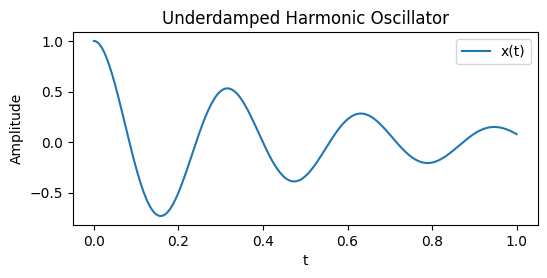

In [4]:

# ---------------------------
# Exact Solution function by Hand 
# ---------------------------

def mass_damper(delta,omega0,t): 
    omega = np.sqrt(omega0**2 - delta**2)
    phi = np.arctan(-delta/omega)
    A = 1/(2*np.cos(phi))
    coss = np.cos(phi+omega*t)
    exp = np.exp(-delta*t)
    y = exp*2*A*coss
    return y

# ---------------------------
# sample ground truth
# ---------------------------
dd = 2
w00=20
times = np.linspace(0,1,300)
yexact = mass_damper(dd,w00,times)
print(len(yexact))

# ---------------------------
# plot 
# ---------------------------

pp.figure(figsize=(6,2.5))
pp.plot(times, yexact,label="x(t)")
pp.xlabel("t")
pp.ylabel("Amplitude")
pp.title("Underdamped Harmonic Oscillator")
pp.legend()
pp.show()


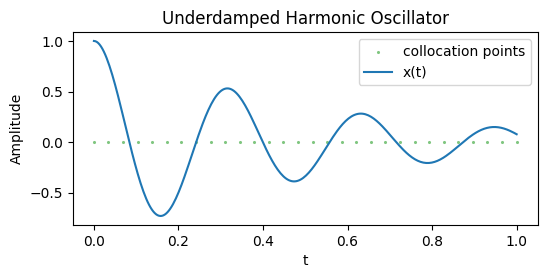

In [5]:
# ---------------------------
# Exact Solution function with solver function (Rutta-Kutta)
# ---------------------------
def underdamped(t, y, delta, omega0):
    x, v = y
    dxdt = v
    dvdt = -2*delta*v - omega0**2*x
    return [dxdt, dvdt]

# ---------------------------
# sample ground truth and set parameters values for underdamped solution
# ---------------------------
delta_val = 2
omega0_val = 20


underdamped_fixed = functools.partial(underdamped, delta=delta_val, omega0=omega0_val)

# Solve the ODE
y0 = [1.0, 0.0]                     # initial displacement=1, velocity=0
t_span = (0, 1)                     # simulate from 0 to 1 s
t_eval = np.linspace(*t_span, 300)  # time points for output
t_eval_col = np.linspace(*t_span, 30)  # reshape for compatibility with solve_ivp

sol = solve_ivp(underdamped_fixed,t_span,y0,t_eval=t_eval)
#print(len(sol.y[0]))
times = sol.t
yexact2 = sol.y[0]
#print(type(yexact2))
ydotexact2 = sol.y[1]

y_pred_phys = solve_ivp(underdamped_fixed,t_span,y0,t_eval=t_eval_col)
y_pred_phys2 = y_pred_phys.y[0]
ydot_pred_phys2 = y_pred_phys.y[1]
#print(len(y_pred_phys2))
# ---------------------------
# plot 
# ---------------------------
pp.figure(figsize=(6,2.5))

pp.scatter (t_eval_col, np.zeros_like(t_eval_col), s=5, lw=0, color="tab:green", label="collocation points", alpha=0.6)
pp.plot(times, yexact2,label="x(t)")
pp.xlabel("t")
pp.ylabel("Amplitude")
pp.title("Underdamped Harmonic Oscillator")
pp.legend()
pp.show()


### Step 3: Simple Neural Networks with and without regularization
1. Defining the simple FCN and make the layers and the activation function a variable
* we use tanh as activation function 
* the output is 1 in this case
* hidden layers have a size of 100 (100 neurons); this can be changed later
* 3 layers to start with 

In [6]:
# ---------------------------
# Define the forward NN - we have two neural network options here, one with nn.Sequential and one with nn.ModuleList. The second one is more flexible and allows us to initialize the weights and biases of the layers in a more controlled way.
# ---------------------------
class FCN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers=3, activation=nn.Tanh):
        super(FCN, self).__init__()
        self.inputlayer = nn.Sequential(nn.Linear(input_size, hidden_size),activation())
        self.hiddenlayers = nn.Sequential(*[nn.Sequential(*[nn.Linear(hidden_size, hidden_size),activation()]) for _ in range(num_layers - 1)])
        self.outputlayer = nn.Linear(hidden_size, output_size)
                                        
    def forward(self, x):
        x = self.inputlayer(x)
        x = self.hiddenlayers(x)
        x = self.outputlayer(x)
        return x
    

class FCNforward(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers=3, activation=nn.Tanh):
        super(FCNforward, self).__init__()
        
        self.activation = activation() # Instantiate the activation function
        
        # Input layer definition
        self.inputlayer = nn.Linear(input_size, hidden_size)
        
        # Hidden layers definition using nn.ModuleList
        self.hiddenlayers = nn.ModuleList([
            nn.Linear(hidden_size, hidden_size) for _ in range(num_layers - 1)
        ])
        
        # Output layer definition
        self.outputlayer = nn.Linear(hidden_size, output_size)
        
        # Initialize weights and biases
        # Combine all layers into one list for easy iteration
        all_layers = [self.inputlayer, *self.hiddenlayers, self.outputlayer]
        
        for layer in all_layers:
            # Weights from a normal distribution (Xavier normal)
            # Recommended gain value for tanh is used by default if activation is specified
            nn.init.xavier_normal_(layer.weight, gain=nn.init.calculate_gain('tanh'))
            # Set biases to zero
            if layer.bias is not None:
                nn.init.zeros_(layer.bias)

    def forward(self, x):
        # Pass input through the input layer and activation
        x = self.activation(self.inputlayer(x))
        
        # Pass through hidden layers with activation
        for layer in self.hiddenlayers:
            x = self.activation(layer(x))
            
        # Pass through the final output layer (no activation here, often preferred for regression/discovery)
        x = self.outputlayer(x)
        
        return x

### Step 3: Define the physics and initial condition loss

$$
L = \lambda_{phys}* L_{phys}(\theta) + \lambda_{ic}* L_{ic}(\theta)
$$


*Now we have to define the loss*

**1. Physics Loss**

Physics PDE residual: 

$$R(t,\theta) = m \hat{x}_{tt} + \hat{x}_{t} + k \hat{x}$$

where
$$\hat{x}_{tt} = \frac{d^2\hat{x}}{dt^2} \quad\text{and}\quad \hat{x}_{t} = \frac{d\hat{x}}{dt}$$

1. Physics loss based on data sampled a collection points: 

$$L_{phys}(\theta) = \frac{1}{N_f} \sum_{i=1}^{N_f} [R(t_f^{i};\theta)]^2$$

**2. Individual condition Loss**

$$
L_{\text{IC}}(\theta)
=
\frac{1}{N_{\text{ic}}}
\sum_{i=1}^{N_{\text{ic}}}
\Big[
\hat{x}\big(t_{\text{ic}}^{\,i};\,\theta\big)
-
x\big(t_{\text{ic}}^{\,i}\big)
\Big]^2
$$


### Step 3: Define the physics loss
1. Define the autograd
2. Define the physics loss as a function
3. Define boundary loss as a function

In [7]:
# ---------------------------
# NExt we define a function to compute the derivatives of the output of the neural network with respect to its input using PyTorch's autograd functionality. This is crucial for physics-informed neural networks, as we need to compute the derivatives to enforce the physical laws in the loss function.
# ---------------------------
def derivates(y,t,order):
    """ This function computes the derivatives of y with respect to x using PyTorch's autograd.
    Args:   y (torch.Tensor): The output tensor for which derivatives are computed. In our case it will be 1. 
            t (torch.Tensor): The input tensor with respect to which derivatives are computed. in this case it is the time t.
            order (int): The order of the derivative to compute. Default is 1.
    Returns:
        torch.Tensor: The computed derivative of y with respect to x.
    Note: y actually has to depend on x for the autograd to work properly.Otherwise it throws an error. 
    """
    for _ in range(order):
        y = torch.autograd.grad(y, t, grad_outputs=torch.ones_like(y,device=y.device),
                                create_graph=True,retain_graph=True)[0] ## needed if called multiple times. 
    return y


In [8]:
# ---------------------------
# This is just a test to check if the autograd is working properly and if the derivatives are computed correctly. We compute the derivative of y = x^2 + cos(x) by hand and compare it with the output of the derivates function. Can be ignored later one but for a decent understanding it might be useful. 
# ---------------------------
def derivate_hand(x):
    """This function computes the derivative of y = x^2 + cos(x) by hand.
    Args:
        x (torch.Tensor): The input tensor.
    Returns:
        torch.Tensor: The computed derivative of y with respect to x.
    Note: This is a manual computation of the derivative for testing purposes.
    """
    dy_dx_hand = 2*x - torch.sin(x)
    dy_dx2_hand = 2 - torch.cos(x)
    return [dy_dx_hand,dy_dx2_hand]

x = torch.randn(4, 4).requires_grad_(True)
y = x**2 + torch.cos(x)
#dy_dx = derivates(y, x)
#dy_dx2 = derivates(y,x,2)
dy_dx = derivates(y, x,1)
dy_dx2 = derivates(y,x,2)
dy_dx_hand,dy_dx2_hand = derivate_hand(x)
print("x:", x)
print("y:", y)
print("dy_dx:", dy_dx)
print("dy_dx2:", dy_dx2)
print("dy_dx_hand:", dy_dx_hand)
print("dy_dx2_hand:", dy_dx2_hand) 

x: tensor([[ 1.4712e+00, -5.6403e-01,  3.4198e-01,  1.4597e+00],
        [ 1.4583e+00, -6.8337e-01, -1.5178e+00,  2.3627e-01],
        [-4.7297e-01,  2.3569e-04,  7.2776e-01,  1.0954e+00],
        [ 1.0631e+00,  1.3503e+00, -3.4000e-01, -8.0749e-01]],
       requires_grad=True)
y: tensor([[2.2639, 1.1632, 1.0590, 2.2416],
        [2.2389, 1.2424, 2.3567, 1.0280],
        [1.1139, 1.0000, 1.2763, 1.6577],
        [1.6163, 2.0421, 1.0584, 1.3434]], grad_fn=<AddBackward0>)
dy_dx: tensor([[ 1.9474e+00, -5.9347e-01,  3.4860e-01,  1.9255e+00],
        [ 1.9229e+00, -7.3533e-01, -2.0371e+00,  2.3846e-01],
        [-4.9041e-01,  2.3569e-04,  7.9032e-01,  1.3018e+00],
        [ 1.2523e+00,  1.7248e+00, -3.4651e-01, -8.9242e-01]],
       grad_fn=<AddBackward0>)
dy_dx2: tensor([[1.9006, 1.1549, 1.0579, 1.8891],
        [1.8877, 1.2245, 1.9471, 1.0278],
        [1.1098, 1.0000, 1.2533, 1.5423],
        [1.5138, 1.7813, 1.0572, 1.3087]], grad_fn=<AddBackward0>)
dy_dx_hand: tensor([[ 1.9474e+00, -5.

In [9]:
# ---------------------------
# Now we define the physics loss function, which computes the residual of the differential equation at the collocation points. This loss will be used to train the neural network to satisfy the physical law represented by the differential equation.
# ---------------------------
def physics_loss(model, t_phys, delta, omega0):
    """This function computes the physics loss for a given model and input.
    Args:
        model (nn.Module): The neural network model.
        x (torch.Tensor): Input tensor.
        delta (float): Damping factor.
        omega0 (float): Natural frequency.
    Returns:
        torch.Tensor: The computed physics loss."""
    y = model(t_phys)
    ydot = derivates(y, t_phys, 1)
    yddot = derivates(y, t_phys,2)
    # Physics equation: y'' + 2*delta*y' + omega0^2*y = 0
    residual = yddot + 2 * delta * ydot + omega0**2 * y
    return torch.mean(residual**2)
   
### initial condition loss
def ic_loss(model,tboundary, y0,dy_dt0):
    """This function computes the initial condition loss for a given model and input.
    Args:
        model (nn.Module): The neural network model.
        t (torch.Tensor): Input tensor.
        y0 (torch.Tensor): Initial condition tensor.
    Returns:
        torch.Tensor: The computed initial condition loss."""
    y = model(tboundary)  # Get model output at t=0
    lossic1 = torch.mean((y - y0)**2)  
    dydt = derivates(y, tboundary, 1)
    lossic2 = torch.mean((dydt - dy_dt0)**2) # Initial condition for y at t=0
   # Get the model output at t=0
    return lossic1,lossic2  # Mean Squared Error for initial condition

Using device: mps
torch.Size([30, 1]) torch.Size([1, 1])
FCN(
  (inputlayer): Sequential(
    (0): Linear(in_features=1, out_features=32, bias=True)
    (1): Tanh()
  )
  (hiddenlayers): Sequential(
    (0): Sequential(
      (0): Linear(in_features=32, out_features=32, bias=True)
      (1): Tanh()
    )
    (1): Sequential(
      (0): Linear(in_features=32, out_features=32, bias=True)
      (1): Tanh()
    )
  )
  (outputlayer): Linear(in_features=32, out_features=1, bias=True)
)
Epoch 0/15001, Loss: 1.0218925476074219, Loss_ic1: 0.9346867203712463, Loss_ic2: 0.04680395498871803, Loss_phys: 825.2545776367188,learning_rate:[0.001]
✅ Stored model at epoch 0


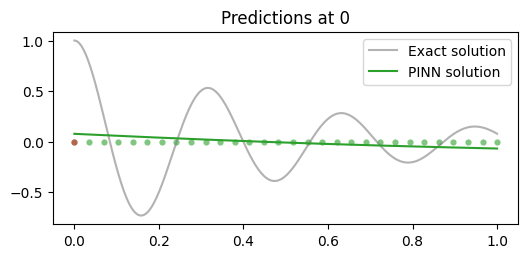

Epoch 500/15001, Loss: 0.18604649603366852, Loss_ic1: 0.049862030893564224, Loss_ic2: 0.00027098279679194093, Loss_phys: 1361.5736083984375,learning_rate:[0.001]
Epoch 1000/15001, Loss: 0.05030006170272827, Loss_ic1: 0.0034201990347355604, Loss_ic2: 0.0034822258166968822, Loss_phys: 465.31640625,learning_rate:[0.001]
Epoch 1500/15001, Loss: 0.03190416842699051, Loss_ic1: 0.001408478943631053, Loss_ic2: 0.00147670553997159, Loss_phys: 303.4801940917969,learning_rate:[0.001]
Epoch 2000/15001, Loss: 0.0247491504997015, Loss_ic1: 0.0008864313713274896, Loss_ic2: 0.00012880776193924248, Loss_phys: 238.49838256835938,learning_rate:[0.001]
Epoch 2500/15001, Loss: 0.013044329360127449, Loss_ic1: 0.00030586571665480733, Loss_ic2: 4.3232120106040384e-08, Loss_phys: 127.38459777832031,learning_rate:[0.001]
Epoch 3000/15001, Loss: 0.009260810911655426, Loss_ic1: 0.00011470795288914815, Loss_ic2: 1.28182961134371e-07, Loss_phys: 91.46090698242188,learning_rate:[0.001]
Epoch 3500/15001, Loss: 0.0087

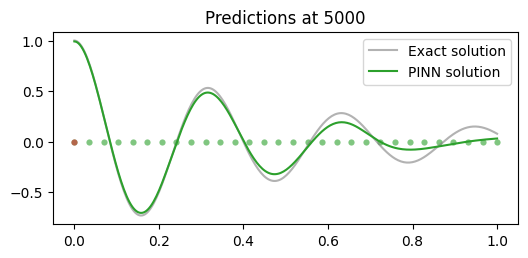

Epoch 5500/15001, Loss: 0.008307868614792824, Loss_ic1: 0.00010274349915562198, Loss_ic2: 0.0017515835352241993, Loss_phys: 80.29966735839844,learning_rate:[0.001]
Epoch 6000/15001, Loss: 0.007392021827399731, Loss_ic1: 6.311641482170671e-05, Loss_ic2: 6.86143321217969e-05, Loss_phys: 73.22044372558594,learning_rate:[0.001]
Epoch 6500/15001, Loss: 0.007016371004283428, Loss_ic1: 6.217289774212986e-05, Loss_ic2: 6.409541786212003e-10, Loss_phys: 69.54198455810547,learning_rate:[0.001]
Epoch 7000/15001, Loss: 0.006615782622247934, Loss_ic1: 5.750765194534324e-05, Loss_ic2: 9.032526726571177e-09, Loss_phys: 65.5827407836914,learning_rate:[0.001]
Epoch 7500/15001, Loss: 0.006162783596664667, Loss_ic1: 5.227956353337504e-05, Loss_ic2: 3.7080298831426717e-09, Loss_phys: 61.10504150390625,learning_rate:[0.001]
Epoch 8000/15001, Loss: 0.005633578170090914, Loss_ic1: 4.6441200538538396e-05, Loss_ic2: 3.872230536217103e-09, Loss_phys: 55.87136459350586,learning_rate:[0.001]
Epoch 8500/15001, Los

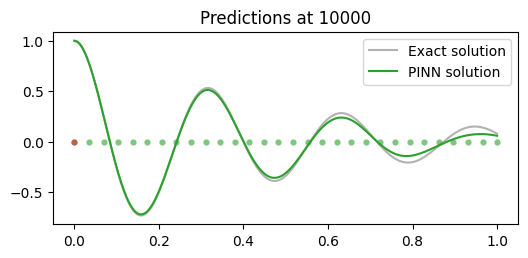

Epoch 10500/15001, Loss: 0.0020551984198391438, Loss_ic1: 1.059082023857627e-05, Loss_ic2: 1.557434714527517e-08, Loss_phys: 20.446060180664062,learning_rate:[0.001]
Epoch 11000/15001, Loss: 0.0015776276122778654, Loss_ic1: 6.97909217706183e-06, Loss_ic2: 1.3415831112695287e-08, Loss_phys: 15.706472396850586,learning_rate:[0.001]
Epoch 11500/15001, Loss: 0.0012670350261032581, Loss_ic1: 6.162084901006892e-06, Loss_ic2: 1.5090222404978704e-05, Loss_phys: 12.593640327453613,learning_rate:[0.001]
Epoch 12000/15001, Loss: 0.01348411850631237, Loss_ic1: 1.0270887287333608e-05, Loss_ic2: 0.02738347463309765, Loss_phys: 107.3550033569336,learning_rate:[0.001]
Epoch 12500/15001, Loss: 0.0008837112691253424, Loss_ic1: 2.1683526938431896e-06, Loss_ic2: 2.3369548074470003e-08, Loss_phys: 8.81540584564209,learning_rate:[0.001]
Epoch 13000/15001, Loss: 0.0007787325303070247, Loss_ic1: 1.7078094742828398e-06, Loss_ic2: 1.3907781237776362e-07, Loss_phys: 7.770108222961426,learning_rate:[0.001]
Epoch 

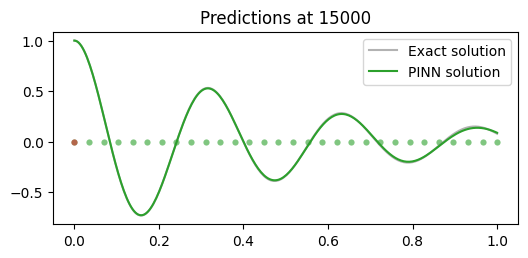

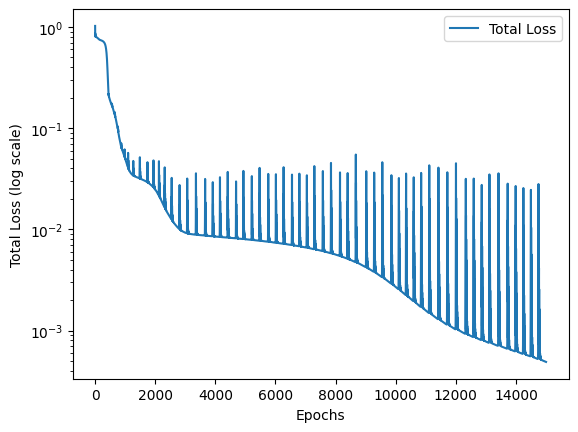

In [10]:
# ---------------------------
# Next we run the training loop for the physics-informed neural network. We compute the physics loss and the initial condition loss at each epoch, combine them into a total loss, and backpropagate to update the model parameters. We also save the model state at regular intervals and generate predictions to visualize the training progress.
# ---------------------------

# manual seed
torch.manual_seed(123) ## Set the seed
print("Using device:", device) # check device
## 1. Define the boundary points as torch tensor [1,1]
t_boundary = torch.tensor([0.0], requires_grad=True).view(-1,1).to(device) # 0 is the boundary point
## 2. Define the collocation points for physics loss [30,1]
t_phys = torch.linspace(0, 1, 30).requires_grad_(True).view(-1,1).to(device) # 30 samples/collocation points over the domain for physics loss
## 3. Define the prediction time frame
t_test = torch.from_numpy(times).to(torch.float).to(device)
## check the size of the tensor
print(t_phys.size(),t_boundary.size()) # (30,1) and (1,1)
#define the model
model = FCN(input_size=1, hidden_size=32, output_size=1, num_layers=3, activation=nn.Tanh)
model.to(device)
print(model) # check the model
#training parameters
lr = 1e-3 # learning rate
omega0,delta=20,2
lambda1,lambda2,lambda3= 1,1e-1,1e-4
y0,dy_dt0=1,0
total_epochs = 15001
# define optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=lr) # Adam optimizer with learning rate lr
lr_scheduler = torch.optim.lr_scheduler.LinearLR(optimizer, start_factor=1.0, end_factor=0.5, total_iters=100)  # Decay LR by a factor of 0.5 every 100 epochs
losses = []
saved_models = {}
epochs = []
model.train()
#training loop
for epoch in range(total_epochs):
    optimizer.zero_grad()
    lossphys = physics_loss(model,t_phys, delta=delta, omega0=omega0) # compute the physics loss
    lossic1,lossic2 = ic_loss(model,t_boundary,y0=y0,dy_dt0=dy_dt0) # compute the boundary loss
    loss = lambda1*lossic1+lambda2*lossic2+lambda3*lossphys # total loss
    loss.backward()
    optimizer.step()
    #lr_scheduler.step()  # Update the learning rate
    losses.append(loss.item())
    if epoch % 500 == 0:
        print(f'Epoch {epoch}/{total_epochs}, Loss: {loss.item()}, Loss_ic1: {lossic1.item()}, Loss_ic2: {lossic2.item()}, Loss_phys: {lossphys.item()},learning_rate:{lr_scheduler.get_last_lr()}') 
    
    if epoch % 5000 == 0: 
        #save models
        saved_models[epoch] = copy.deepcopy(model.state_dict())  # Store the model state
        print(f"✅ Stored model at epoch {epoch}")
        #generate predictions
        model.eval()
        with torch.no_grad():
            out = model(t_test.reshape(len(times), -1))
            y_pred = out
        pp.figure(figsize=(6,2.5))
        pp.scatter(t_phys[:,0].detach().cpu().numpy(), 
                   torch.zeros_like(t_phys)[:,0].cpu(), s=20, lw=0, color="tab:green", alpha=0.6)
        pp.scatter(t_boundary[:,0].detach().cpu().numpy(), 
                   torch.zeros_like(t_boundary)[:,0].detach().cpu().numpy(), s=20, lw=0, color="tab:red", alpha=0.6)
        pp.plot(t_test.detach().cpu().numpy(), yexact, label="Exact solution", color="tab:grey", alpha=0.6)
        pp.plot(t_test.detach().cpu().numpy(), y_pred[:,0].detach().cpu().numpy(), label="PINN solution", color="tab:green")
        pp.title(f"Predictions at {epoch}")
        pp.legend()
        pp.show()
        epochs.append(epoch)
        #switch back to model train
        model.train()

pp.plot(losses)
pp.yscale('log')
pp.xlabel("Epochs")
pp.ylabel("Total Loss (log scale)")
pp.legend(['Total Loss'])

Running config: {'model_type': <class '__main__.FCN'>, 'lr': 0.001, 'hidden_size': 32, 'num_layers': 3, 'lambda1': 1, 'lambda2': 0.1, 'lambda3': 0.0001}
Using device: mps
Epoch 0/15001, Loss: 1.0218925476074219, Loss_ic1: 0.9346867203712463, Loss_ic2: 0.04680395498871803, Loss_phys: 825.2545776367188
✅ Stored model at epoch 0
Epoch 500/15001, Loss: 0.18606019020080566, Loss_ic1: 0.049864426255226135, Loss_ic2: 0.0003162075881846249, Loss_phys: 1361.6414794921875
Epoch 1000/15001, Loss: 0.05031846463680267, Loss_ic1: 0.003446791786700487, Loss_ic2: 8.958421858551446e-06, Loss_phys: 468.707763671875
Epoch 1500/15001, Loss: 0.03205352649092674, Loss_ic1: 0.00114839943125844, Loss_ic2: 0.00145955930929631, Loss_phys: 307.5917053222656
Epoch 2000/15001, Loss: 0.02523462288081646, Loss_ic1: 0.000894566997885704, Loss_ic2: 9.064277719517122e-07, Loss_phys: 243.399658203125
Epoch 2500/15001, Loss: 0.014387843199074268, Loss_ic1: 0.00039418169762939215, Loss_ic2: 0.002933949464932084, Loss_phys

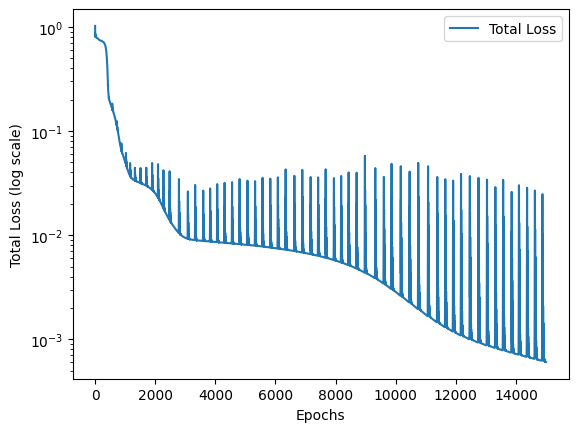

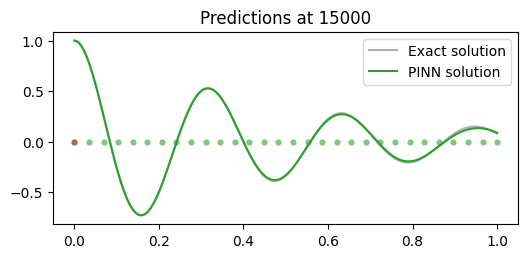

Running config: {'model_type': <class '__main__.FCN'>, 'lr': 0.001, 'hidden_size': 32, 'num_layers': 3, 'lambda1': 1, 'lambda2': 0.1, 'lambda3': 1e-05}
Using device: mps
Epoch 0/15001, Loss: 1.0218925476074219, Loss_ic1: 0.9346867203712463, Loss_ic2: 0.04680395498871803, Loss_phys: 825.2545776367188
✅ Stored model at epoch 0
Epoch 500/15001, Loss: 0.18606019020080566, Loss_ic1: 0.049864426255226135, Loss_ic2: 0.0003162075881846249, Loss_phys: 1361.6414794921875
Epoch 1000/15001, Loss: 0.05031846463680267, Loss_ic1: 0.003446791786700487, Loss_ic2: 8.958421858551446e-06, Loss_phys: 468.707763671875
Epoch 1500/15001, Loss: 0.03205352649092674, Loss_ic1: 0.00114839943125844, Loss_ic2: 0.00145955930929631, Loss_phys: 307.5917053222656
Epoch 2000/15001, Loss: 0.02523462288081646, Loss_ic1: 0.000894566997885704, Loss_ic2: 9.064277719517122e-07, Loss_phys: 243.399658203125
Epoch 2500/15001, Loss: 0.014387843199074268, Loss_ic1: 0.00039418169762939215, Loss_ic2: 0.002933949464932084, Loss_phys:

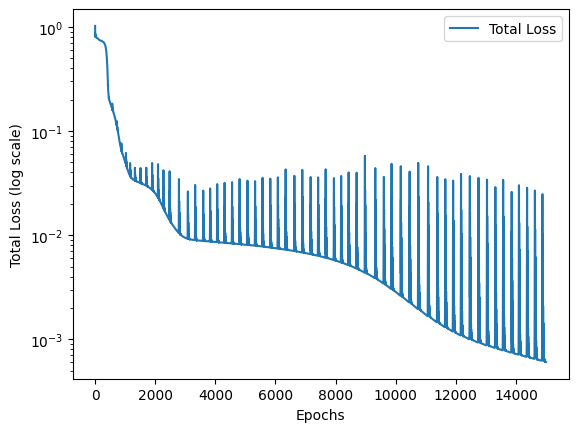

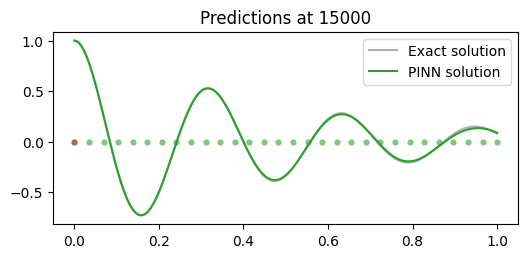

Running config: {'model_type': <class '__main__.FCN'>, 'lr': 0.001, 'hidden_size': 32, 'num_layers': 3, 'lambda1': 1, 'lambda2': 0.01, 'lambda3': 0.0001}
Using device: mps
Epoch 0/15001, Loss: 1.0218925476074219, Loss_ic1: 0.9346867203712463, Loss_ic2: 0.04680395498871803, Loss_phys: 825.2545776367188
✅ Stored model at epoch 0
Epoch 500/15001, Loss: 0.18606019020080566, Loss_ic1: 0.049864426255226135, Loss_ic2: 0.0003162075881846249, Loss_phys: 1361.6414794921875
Epoch 1000/15001, Loss: 0.05031846463680267, Loss_ic1: 0.003446791786700487, Loss_ic2: 8.958421858551446e-06, Loss_phys: 468.707763671875
Epoch 1500/15001, Loss: 0.03205352649092674, Loss_ic1: 0.00114839943125844, Loss_ic2: 0.00145955930929631, Loss_phys: 307.5917053222656
Epoch 2000/15001, Loss: 0.02523462288081646, Loss_ic1: 0.000894566997885704, Loss_ic2: 9.064277719517122e-07, Loss_phys: 243.399658203125
Epoch 2500/15001, Loss: 0.014387843199074268, Loss_ic1: 0.00039418169762939215, Loss_ic2: 0.002933949464932084, Loss_phy

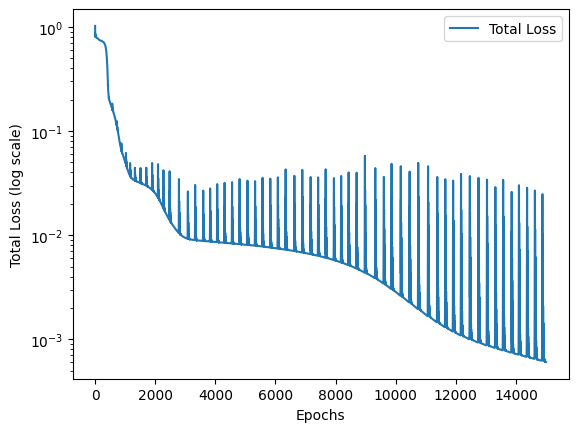

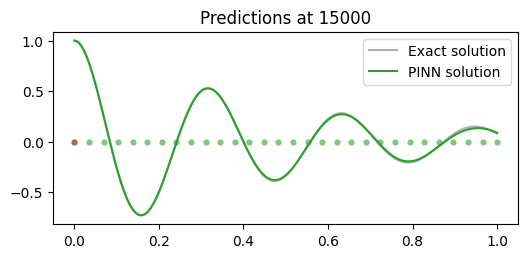

Running config: {'model_type': <class '__main__.FCN'>, 'lr': 0.001, 'hidden_size': 32, 'num_layers': 3, 'lambda1': 1, 'lambda2': 0.01, 'lambda3': 1e-05}
Using device: mps
Epoch 0/15001, Loss: 1.0218925476074219, Loss_ic1: 0.9346867203712463, Loss_ic2: 0.04680395498871803, Loss_phys: 825.2545776367188
✅ Stored model at epoch 0
Epoch 500/15001, Loss: 0.18606019020080566, Loss_ic1: 0.049864426255226135, Loss_ic2: 0.0003162075881846249, Loss_phys: 1361.6414794921875
Epoch 1000/15001, Loss: 0.05031846463680267, Loss_ic1: 0.003446791786700487, Loss_ic2: 8.958421858551446e-06, Loss_phys: 468.707763671875
Epoch 1500/15001, Loss: 0.03205352649092674, Loss_ic1: 0.00114839943125844, Loss_ic2: 0.00145955930929631, Loss_phys: 307.5917053222656
Epoch 2000/15001, Loss: 0.02523462288081646, Loss_ic1: 0.000894566997885704, Loss_ic2: 9.064277719517122e-07, Loss_phys: 243.399658203125
Epoch 2500/15001, Loss: 0.014387843199074268, Loss_ic1: 0.00039418169762939215, Loss_ic2: 0.002933949464932084, Loss_phys

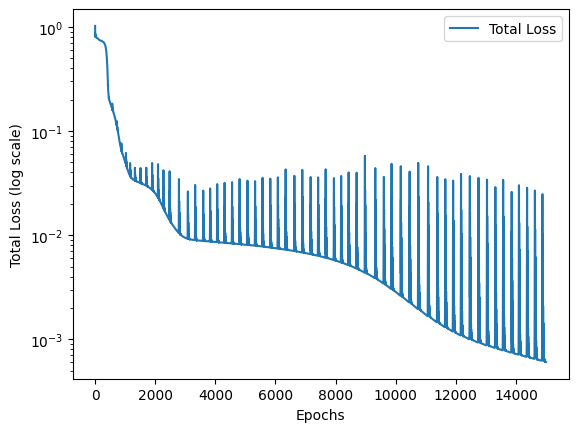

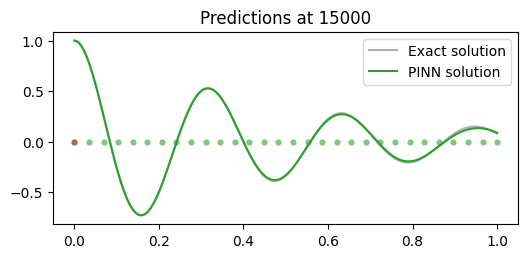

Running config: {'model_type': <class '__main__.FCN'>, 'lr': 0.001, 'hidden_size': 32, 'num_layers': 3, 'lambda1': 10, 'lambda2': 0.1, 'lambda3': 0.0001}
Using device: mps
Epoch 0/15001, Loss: 1.0218925476074219, Loss_ic1: 0.9346867203712463, Loss_ic2: 0.04680395498871803, Loss_phys: 825.2545776367188
✅ Stored model at epoch 0
Epoch 500/15001, Loss: 0.18606019020080566, Loss_ic1: 0.049864426255226135, Loss_ic2: 0.0003162075881846249, Loss_phys: 1361.6414794921875
Epoch 1000/15001, Loss: 0.05031846463680267, Loss_ic1: 0.003446791786700487, Loss_ic2: 8.958421858551446e-06, Loss_phys: 468.707763671875
Epoch 1500/15001, Loss: 0.03205352649092674, Loss_ic1: 0.00114839943125844, Loss_ic2: 0.00145955930929631, Loss_phys: 307.5917053222656
Epoch 2000/15001, Loss: 0.02523462288081646, Loss_ic1: 0.000894566997885704, Loss_ic2: 9.064277719517122e-07, Loss_phys: 243.399658203125
Epoch 2500/15001, Loss: 0.014387843199074268, Loss_ic1: 0.00039418169762939215, Loss_ic2: 0.002933949464932084, Loss_phy

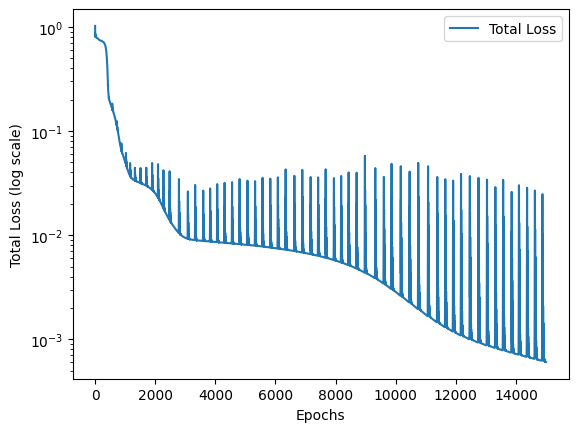

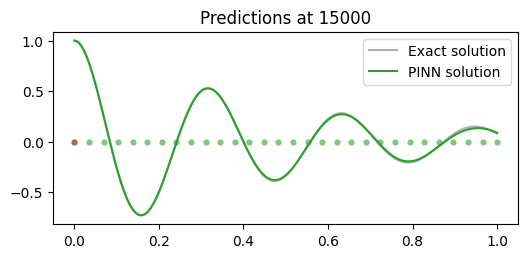

Running config: {'model_type': <class '__main__.FCN'>, 'lr': 0.001, 'hidden_size': 32, 'num_layers': 3, 'lambda1': 10, 'lambda2': 0.1, 'lambda3': 1e-05}
Using device: mps
Epoch 0/15001, Loss: 1.0218925476074219, Loss_ic1: 0.9346867203712463, Loss_ic2: 0.04680395498871803, Loss_phys: 825.2545776367188
✅ Stored model at epoch 0
Epoch 500/15001, Loss: 0.18606019020080566, Loss_ic1: 0.049864426255226135, Loss_ic2: 0.0003162075881846249, Loss_phys: 1361.6414794921875
Epoch 1000/15001, Loss: 0.05031846463680267, Loss_ic1: 0.003446791786700487, Loss_ic2: 8.958421858551446e-06, Loss_phys: 468.707763671875
Epoch 1500/15001, Loss: 0.03205352649092674, Loss_ic1: 0.00114839943125844, Loss_ic2: 0.00145955930929631, Loss_phys: 307.5917053222656
Epoch 2000/15001, Loss: 0.02523462288081646, Loss_ic1: 0.000894566997885704, Loss_ic2: 9.064277719517122e-07, Loss_phys: 243.399658203125
Epoch 2500/15001, Loss: 0.014387843199074268, Loss_ic1: 0.00039418169762939215, Loss_ic2: 0.002933949464932084, Loss_phys

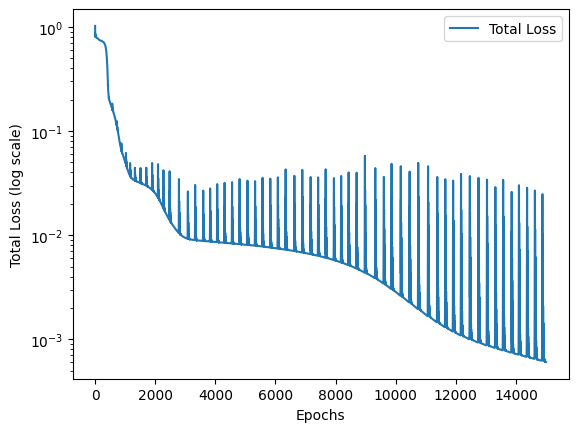

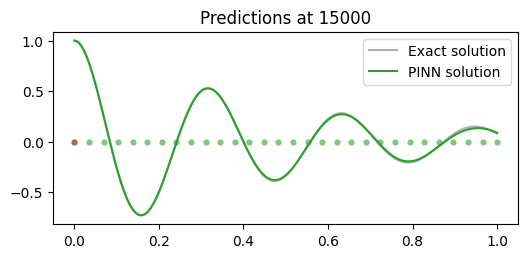

Running config: {'model_type': <class '__main__.FCN'>, 'lr': 0.001, 'hidden_size': 32, 'num_layers': 3, 'lambda1': 10, 'lambda2': 0.01, 'lambda3': 0.0001}
Using device: mps
Epoch 0/15001, Loss: 1.0218925476074219, Loss_ic1: 0.9346867203712463, Loss_ic2: 0.04680395498871803, Loss_phys: 825.2545776367188
✅ Stored model at epoch 0
Epoch 500/15001, Loss: 0.18606019020080566, Loss_ic1: 0.049864426255226135, Loss_ic2: 0.0003162075881846249, Loss_phys: 1361.6414794921875
Epoch 1000/15001, Loss: 0.05031846463680267, Loss_ic1: 0.003446791786700487, Loss_ic2: 8.958421858551446e-06, Loss_phys: 468.707763671875
Epoch 1500/15001, Loss: 0.03205352649092674, Loss_ic1: 0.00114839943125844, Loss_ic2: 0.00145955930929631, Loss_phys: 307.5917053222656
Epoch 2000/15001, Loss: 0.02523462288081646, Loss_ic1: 0.000894566997885704, Loss_ic2: 9.064277719517122e-07, Loss_phys: 243.399658203125
Epoch 2500/15001, Loss: 0.014387843199074268, Loss_ic1: 0.00039418169762939215, Loss_ic2: 0.002933949464932084, Loss_ph

KeyboardInterrupt: 

In [18]:
# ---------------------------
# Now we are building some sweeps to find the best configurations for the forward model. We define a configuration dictionary with different values for the hyperparameters and then we create a list of all possible combinations of these hyperparameters using itertools.product. We also define a function to run each experiment with a given configuration, which includes the training loop and the evaluation of the model. Finally, we run the sweeps for all configurations and store the results.
# ---------------------------

from itertools import product

# Add model type to sweep config
sweep_config = {
    "model_type": [FCN, FCNforward],
    "lr": [1e-3, 1e-4],
    "hidden_size": [32, 64],
    "num_layers": [3, 4],
    "lambda1": [1, 10],
    "lambda2": [1e-1, 1e-2],
    "lambda3": [1e-4, 1e-5]
}

configs = list(product(*sweep_config.values()))

def run_forward_sweep(model_type, lr, hidden_size, num_layers, **kwargs):

    torch.manual_seed(123)
    print("Using device:", device)
    
    y0,dy_dt0=1,0
    total_epochs = 15001
    model = model_type(
            input_size=1,
            hidden_size=hidden_size,
            output_size=1,
            num_layers=num_layers,
            activation=nn.Tanh if model_type is FCN else nn.Tanh  # adjust if needed
        ).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr) # Adam optimizer with learning rate lr
    losses = []
    saved_models = {}
    epochs = []
    model.train()


    #training loop
    for epoch in range(total_epochs):


        optimizer.zero_grad()

        # Compute losses
        lossphys = physics_loss(model,t_phys, delta=delta, omega0=omega0) # compute the physics loss
        lossic1,lossic2 = ic_loss(model,t_boundary,y0=y0,dy_dt0=dy_dt0) # compute the boundary loss
        loss = lambda1*lossic1+lambda2*lossic2+lambda3*lossphys # total loss

        # Backpropagation
        loss.backward()
        optimizer.step()


        #lr_scheduler.step()  # Update the learning rate

        # Logging
        losses.append(loss.item())

        if epoch % 500 == 0:
            print(f'Epoch {epoch}/{total_epochs}, Loss: {loss.item()}, Loss_ic1: {lossic1.item()}, Loss_ic2: {lossic2.item()}, Loss_phys: {lossphys.item()}') 
        
        if epoch % 5000 == 0: 
            #save models
            saved_models[epoch] = copy.deepcopy(model.state_dict())  # Store the model state
            print(f"✅ Stored model at epoch {epoch}")

    # --- Plot losses ---
    
    pp.plot(losses)
    pp.yscale('log')
    pp.xlabel("Epochs")
    pp.ylabel("Total Loss (log scale)")
    pp.legend(['Total Loss'])
            
    # --- Plot predictions ---
    model.eval()
    with torch.no_grad():
        out = model(t_test.reshape(len(times), -1))
        y_pred = out
    
    pp.figure(figsize=(6,2.5))
    pp.scatter(t_phys[:,0].detach().cpu().numpy(), 
            torch.zeros_like(t_phys)[:,0].cpu(), s=20, lw=0, color="tab:green", alpha=0.6)
    pp.scatter(t_boundary[:,0].detach().cpu().numpy(), 
            torch.zeros_like(t_boundary)[:,0].detach().cpu().numpy(), s=20, lw=0, color="tab:red", alpha=0.6)
    pp.plot(t_test.detach().cpu().numpy(), yexact, label="Exact solution", color="tab:grey", alpha=0.6)
    pp.plot(t_test.detach().cpu().numpy(), y_pred[:,0].detach().cpu().numpy(), label="PINN solution", color="tab:green")
    pp.title(f"Predictions at {epoch}")
    pp.legend()
    pp.show()
    epochs.append(epoch)
    #switch back to model train
    model.train()

# Run sweeps
for cfg in configs:
    cfg_dict = dict(zip(sweep_config.keys(), cfg))
    print(f"Running config: {cfg_dict}")
    run_forward_sweep(**cfg_dict)

## Building an inverse PINNs

Now it gets more interesting for system ID! 

In [41]:
# ---------------------------
# Now we create a  neural network for discovery, which has learnable parameters for the damping factor and the eigen frequency. This allows us to not only fit the data but also discover the underlying physical parameters from the data.
# ---------------------------

class FCNdiscovery(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers=3, activation=nn.Tanh):
        super(FCNdiscovery, self).__init__()
        self.inputlayer = nn.Sequential(nn.Linear(input_size, hidden_size),activation())
        self.hiddenlayers = nn.Sequential(*[nn.Sequential(*[nn.Linear(hidden_size, hidden_size),activation()]) for _ in range(num_layers - 1)])
        self.outputlayer = nn.Linear(hidden_size, output_size)
        self.mu = nn.Parameter(data=torch.tensor([0.01])) # this defines the learnable parameters. 
        self.omega = nn.Parameter(data=torch.tensor([0.01]))
        
    # @property
    # def mu(self):
    #     # stabilizes gradients, forces positivity
    #     return torch.nn.functional.softplus(self.mu) + 1e-6

    # # @property
    # def omega(self):
    #     return torch.nn.functional.softplus(self._omega) + 1e-6

                                         
    def forward(self, x):
        x = self.inputlayer(x)
        x = self.hiddenlayers(x)
        x = self.outputlayer(x)
        return x
    
class FCNinverse(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers=3, activation=nn.Tanh):
        super(FCNinverse, self).__init__()
        
        self.activation = activation() # Instantiate the activation function
        
        # Input layer definition
        self.inputlayer = nn.Linear(input_size, hidden_size)
        
        # Hidden layers definition using nn.ModuleList
        self.hiddenlayers = nn.ModuleList([
            nn.Linear(hidden_size, hidden_size) for _ in range(num_layers - 1)
        ])
        
        # Output layer definition
        self.outputlayer = nn.Linear(hidden_size, output_size)
        
        # Initialize weights and biases
        # Combine all layers into one list for easy iteration
        all_layers = [self.inputlayer, *self.hiddenlayers, self.outputlayer]
        
        for layer in all_layers:
            # Weights from a normal distribution (Xavier normal)
            # Recommended gain value for tanh is used by default if activation is specified
            nn.init.xavier_normal_(layer.weight, gain=nn.init.calculate_gain('tanh'))
            # Set biases to zero
            if layer.bias is not None:
                nn.init.zeros_(layer.bias)

        # Define learnable parameters mu and omega
        # Use nn.Parameter for tensors that should be part of the model's parameters
        self.mu = nn.Parameter(data=torch.tensor([0.01]))
        self.omega = nn.Parameter(data=torch.tensor([0.01]))

    def forward(self, x):
        # Pass input through the input layer and activation
        x = self.activation(self.inputlayer(x))
        
        # Pass through hidden layers with activation
        for layer in self.hiddenlayers:
            x = self.activation(layer(x))
            
        # Pass through the final output layer (no activation here, often preferred for regression/discovery)
        x = self.outputlayer(x)
        
        return x

In [31]:
# ---------------------------
# Now we define the physics loss function for the discovery model, which includes the learnable parameters for the damping factor and the eigen frequency. This allows us to compute the residual of the differential equation using the learnable parameters and train the model to discover these parameters from the data.
# ---------------------------

def physics_loss_inverse(model, t_phys):
    """This function computes the physics loss for a given model and input.
    Args:
        model (nn.Module): The neural network model.
        x (torch.Tensor): Input tensor.
        delta (float): Damping factor.
        omega0 (float): Natural frequency.
    Returns:
        torch.Tensor: The computed physics loss."""
    y = model(t_phys)
    ydot = derivates(y, t_phys, 1)
    yddot = derivates(y, t_phys,2)
    # Physics equation: y'' + 2*delta*y' + omega0^2*y = 0
    residual = yddot + 2 * model.mu * ydot + model.omega**2 * y # adding the learnable parameter r to learn omega
    return torch.mean(residual**2)

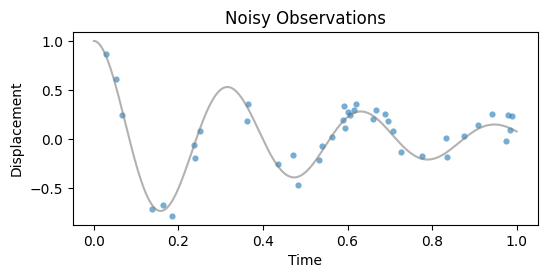

In [32]:
# ---------------------------
# Create the noisy observations for the discovery problem. We use the same solver as before to generate the exact solution and then add some noise to it to create the observations. We will use these observations to train the discovery model and see if it can learn the underlying parameters from the noisy data.
# ---------------------------
delta,omega0=2,20
y0 = [1, 0]  # initial conditions
t_span = (0, 1)
t_obs = np.random.rand(40)
t_obs.sort()
#print(t_obs)
sol = solve_ivp(underdamped_fixed,t_span,y0,t_eval=t_obs)
y_obs = sol.y[0] +np.random.normal(0, 0.1, size=sol.y[0].shape) # add noise
pp.figure(figsize=(6,2.5))
pp.scatter(t_obs, y_obs, s=20, lw=0, label="Noisy solution",color="tab:blue", alpha=0.6)
pp.plot(times, yexact, label="Exact solution", color="tab:grey", alpha=0.6)
pp.title("Noisy Observations")
pp.xlabel("Time")
pp.ylabel("Displacement")
pp.show()
t_obs = torch.from_numpy(t_obs).to(torch.float).view(-1,1).to(device)
y_obs = torch.from_numpy(y_obs).to(torch.float).view(-1,1).to(device)


Using device: mps
torch.Size([30, 1]) torch.Size([1, 1])
FCNdiscovery(
  (inputlayer): Sequential(
    (0): Linear(in_features=1, out_features=32, bias=True)
    (1): Tanh()
  )
  (hiddenlayers): Sequential(
    (0): Sequential(
      (0): Linear(in_features=32, out_features=32, bias=True)
      (1): Tanh()
    )
    (1): Sequential(
      (0): Linear(in_features=32, out_features=32, bias=True)
      (1): Tanh()
    )
  )
  (outputlayer): Linear(in_features=32, out_features=1, bias=True)
)
Epoch 0/25001 | Total Loss: 1343.678589 | Data Loss: 0.134366 | Physics Loss: 0.014725
✅ Stored model at epoch 0
Learned mu: 0.010999999940395355, Learned omega: 0.010999960824847221


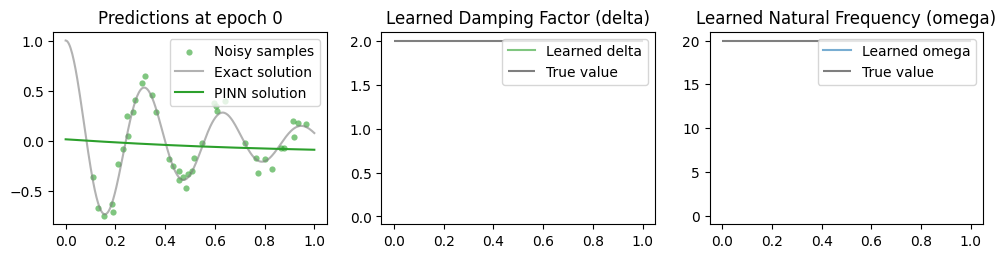

Epoch 1000/25001 | Total Loss: 936.714233 | Data Loss: 0.080884 | Physics Loss: 127.878761
Epoch 2000/25001 | Total Loss: 920.158875 | Data Loss: 0.079794 | Physics Loss: 122.221817


KeyboardInterrupt: 

In [23]:
# ---------------------------
# Training loop for the discovery model. We compute the physics loss using the learnable parameters and the data loss using the noisy observations. We combine these losses into a total loss and backpropagate to update both the model parameters and the learnable physical parameters. We also save the model state at regular intervals and generate predictions to visualize the training progress.
# ---------------------------
torch.manual_seed(123)
print("Using device:", device)

# Boundary and collocation points
t_boundary = torch.tensor([0.0], requires_grad=True).view(-1,1).to(device)
t_phys = torch.linspace(0, 1, 30).requires_grad_(True).view(-1,1).to(device)
t_test = torch.from_numpy(times).to(torch.float).to(device)

print(t_phys.size(), t_boundary.size())

# Define the model
model = FCNdiscovery(input_size=1, hidden_size=32, output_size=1, num_layers=3, activation=torch.nn.Tanh)
model.to(device)
print(model)
# for name, param in model.named_parameters():
#     print(name, param)

# --- Training parameters ---
lr_nn = 1e-3       # learning rate for network weights
lr_param = 1e-3    # faster learning for physical parameters
lambda_data = 1e4  # weight for data loss
lambda_phys = 1  # weight for physics loss
y0, dy_dt0 = 1, 0
total_epochs = 25001

# Optimizer with separate learning rates
optimizer = torch.optim.Adam([
    {'params': [p for n,p in model.named_parameters() if n not in ['mu','omega']], 'lr': lr_nn},
    {'params': [model.mu, model.omega], 'lr': lr_param}
])

# --- Training loop ---
losses = []
saved_models = {}
learned_mu = []
learned_omega = []
epochs = []

model.train()
for epoch in range(total_epochs):
    optimizer.zero_grad()
    
    # Compute losses
    loss_phys = physics_loss_inverse(model, t_phys)
    loss_data = torch.mean((model(t_obs) - y_obs)**2)
    loss = lambda_data*loss_data + lambda_phys*loss_phys
    
    # Backpropagation
    loss.backward()
    optimizer.step()
    
    # Logging
    losses.append(loss.item())
    learned_mu.append(model.mu.item())
    learned_omega.append(model.omega.item())
    
    if epoch % 1000 == 0:
        print(f"Epoch {epoch}/{total_epochs} | Total Loss: {loss.item():.6f} | Data Loss: {loss_data.item():.6f} | Physics Loss: {loss_phys.item():.6f}")
    
    # Save models and plot progress every 5000 epochs
    if epoch % 5000 == 0:
        saved_models[epoch] = copy.deepcopy(model.state_dict())
        print(f"✅ Stored model at epoch {epoch}")
        print(f"Learned mu: {learned_mu[-1]}, Learned omega: {learned_omega[-1]}")
        
        model.eval()
        with torch.no_grad():
            y_pred = model(t_test.reshape(len(times), -1))
        
        # --- Plot predictions ---
        fig, axs = pp.subplots(1,3, figsize=(12,2.5))
        
        # Plot data vs predictions
        axs[0].scatter(t_obs[:,0].detach().cpu(), y_obs[:,0].cpu(), s=20, lw=0, label="Noisy samples", color="tab:green", alpha=0.6)
        axs[0].plot(t_test.detach().cpu(), yexact, label="Exact solution", color="tab:grey", alpha=0.6)
        axs[0].plot(t_test.detach().cpu(), y_pred[:,0].detach().cpu(), label="PINN solution", color="tab:green")
        axs[0].set_title(f"Predictions at epoch {epoch}")
        axs[0].legend()
        
        # Plot learned mu
        axs[1].plot(learned_mu, label="Learned delta", color="tab:green", alpha=0.6)
        axs[1].hlines(delta, 0, len(learned_mu), label="True value", color="tab:grey")
        axs[1].set_title("Learned Damping Factor (delta)")
        axs[1].legend()
        
        # Plot learned omega
        axs[2].plot(learned_omega, label="Learned omega", color="tab:blue", alpha=0.6)
        axs[2].hlines(omega0, 0, len(learned_mu), label="True value", color="tab:grey")
        axs[2].set_title("Learned Natural Frequency (omega)")
        axs[2].legend()
        
        pp.show()
        model.train()

# Plot total loss
pp.plot(losses)
pp.yscale('log')
pp.xlabel("Epochs")
pp.ylabel("Total Loss (log scale)")
pp.legend(['Total Loss'])
pp.show()

In [38]:
# ---------------------------
# Now we add some sweeps to find the best configurations
# ---------------------------
from itertools import product

#Define a configuration dictionary
sweep_config = {
    "lr_nn": [1e-3, 1e-4],
    "lr_param": [1e-3, 1e-4],
    "lambda_data": [5e3, 1e3],
    "lambda_phys": [0.5, 0.1],
    "mu_init": [0.1],
    "omega_init": [1.0],
}

#Define the sweeps 
configs = list(product(*sweep_config.values()))

print("Total experiments:", len(configs))

#Build the model with the sweeps

def build_model(mu_init, omega_init):
    model2 = FCNinverse(
        input_size=1,
        hidden_size=32,
        output_size=1,
        num_layers=3,
        activation=nn.Tanh
    )
    model2.mu = nn.Parameter(torch.tensor([mu_init], dtype=torch.float32))
    model2.omega = nn.Parameter(torch.tensor([omega_init], dtype=torch.float32))
    return model2.to(device)

Total experiments: 16


In [42]:
# ---------------------------
# Now we define a function to run each experiment.
# ---------------------------

def run_experiment(config_id, lr_nn, lr_param, lambda_data, lambda_phys, mu_init, omega_init):

    # --- Training setup ---
    torch.manual_seed(123)
    print("Using device:", device)

    # Boundary and collocation points
    t_phys = torch.linspace(0, 1, 30).requires_grad_(True).view(-1,1).to(device)
    #t_test = torch.from_numpy(times).to(torch.float).to(device)

    print(t_phys.size())

    # Define the model

    model2 = build_model(mu_init, omega_init)

    optimizer = torch.optim.Adam([
    {'params': [p for n,p in model2.named_parameters() if n not in ['mu','omega']], 'lr': lr_nn},
    {'params': [model2.mu, model2.omega], 'lr': lr_param}
    ])

    learned_mu = []
    learned_omega = []
    losses = []

    # --- Training loop ---

    for epoch in range(25001):  # shorter training for sweeps
        
        optimizer.zero_grad()

        # Compute losses
        loss_phys = physics_loss_inverse(model2, t_phys)
        loss_data = torch.mean((model2(t_obs) - y_obs)**2)
        loss = lambda_phys* loss_phys + lambda_data * loss_data

        # Backpropagation
        loss.backward()
        optimizer.step()

        # Logging
        losses.append(loss.item())
        learned_mu.append(model2.mu.item())
        learned_omega.append(model2.omega.item())
    
      
    # Final errors
    mu_error = abs(model2.mu.item() - delta) ## comparison with the ground truth data (defined above)
    omega_error = abs(model2.omega.item() - omega0) ## comparison with the ground truth data (defined above)

     # --- predictions ---

    model2.eval()
    
    with torch.no_grad():
        predictions = model2(t_test.reshape(len(times), -1))

    return {
        "config": config_id,
        "lr_nn": lr_nn,
        "lr_param": lr_param,
        "lambda_phys": lambda_phys,
        "lambda_data": lambda_data,
        "mu_init": mu_init,
        "omega_init": omega_init,
        "mu_final": model2.mu.item(),
        "omega_final": model2.omega.item(),
        "mu_error": mu_error,
        "omega_error": omega_error,
        "losses": losses,
        'learned_mu': learned_mu,
        'learned_omega': learned_omega,
        'predictions': predictions
    }

In [43]:
# ---------------------------
# Now we run the experiments for all configurations and store the results in a list.
# ---------------------------

results = []

dtype = [
    ("config",int),
    ("lr",float),
    ("lr_param",float),
    ("lambda_phys",float),
    ("lambda_data",float),
    ("mu_init",float),
    ("omega_init",float),
    ("mu_final",float),
    ("omega_final",float),
    ("mu_error",float),
    ("omega_error",float),
    ("losses",float),
]


for i, cfg in enumerate(configs):
    keys = list(sweep_config.keys())
    cfg_dict = dict(zip(keys,cfg)) 
    print(f"\nRunning config {i+1}/{len(configs)}, with configuration {cfg_dict}, and {cfg}")

    out = run_experiment(i,**cfg_dict) 
    results.append(out)
    print(f"results for {i+1}/{len(configs)}: {out['mu_final']}, {out['omega_final']}, errors: {out['mu_error']}, {out['omega_error']}")







Running config 1/16, with configuration {'lr_nn': 0.001, 'lr_param': 0.001, 'lambda_data': 5000.0, 'lambda_phys': 0.5, 'mu_init': 0.1, 'omega_init': 1.0}, and (0.001, 0.001, 5000.0, 0.5, 0.1, 1.0)
Using device: mps
torch.Size([30, 1])
results for 1/16: 1.9789410829544067, 19.962291717529297, errors: 0.02105891704559326, 0.037708282470703125

Running config 2/16, with configuration {'lr_nn': 0.001, 'lr_param': 0.001, 'lambda_data': 5000.0, 'lambda_phys': 0.1, 'mu_init': 0.1, 'omega_init': 1.0}, and (0.001, 0.001, 5000.0, 0.1, 0.1, 1.0)
Using device: mps
torch.Size([30, 1])
results for 2/16: 2.054372787475586, 20.031978607177734, errors: 0.05437278747558594, 0.031978607177734375

Running config 3/16, with configuration {'lr_nn': 0.001, 'lr_param': 0.001, 'lambda_data': 1000.0, 'lambda_phys': 0.5, 'mu_init': 0.1, 'omega_init': 1.0}, and (0.001, 0.001, 1000.0, 0.5, 0.1, 1.0)
Using device: mps
torch.Size([30, 1])
results for 3/16: 4.927997589111328, 19.402334213256836, errors: 2.9279975891

KeyboardInterrupt: 

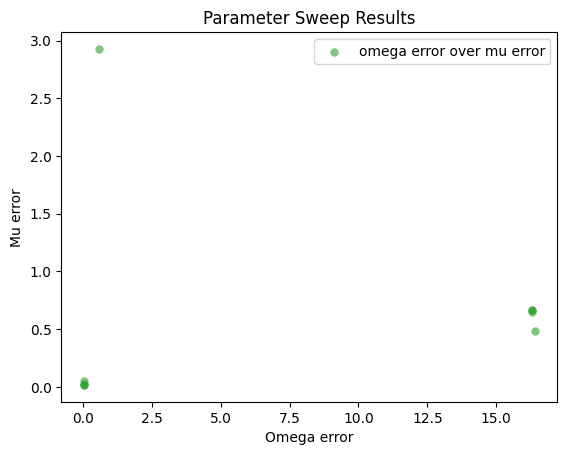

In [44]:
# ---------------------------
# Now we can analyze the results of the sweeps. We can plot the errors for the learned parameters to see which configurations performed better in terms of discovering the underlying physical parameters.
# ---------------------------
pp.scatter([r["omega_error"] for r in results], [r["mu_error"] for r in results], lw=0, label="omega error over mu error", color="tab:green", alpha=0.6)
pp. xlabel("Omega error")
pp. ylabel("Mu error")
pp.title("Parameter Sweep Results")
pp.legend()
pp.show()

Best configuration: Number configuration: 8  LR NN: 0.0001 LR Param: 0.001 Lambda Phys: 0.5 Lambda Data: 5000.0 Mu Init: 0.1 Omega Init: 1.0 Final Mu: 1.9828801155090332 Final Omega: 19.96941375732422 Mu Error: 0.017119884490966797 Omega Error: 0.03058624267578125


/var/folders/6_/z3gbw9gx3_q93ppl8nb15klh0000gq/T/ipykernel_60915/126050066.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[0].legend()


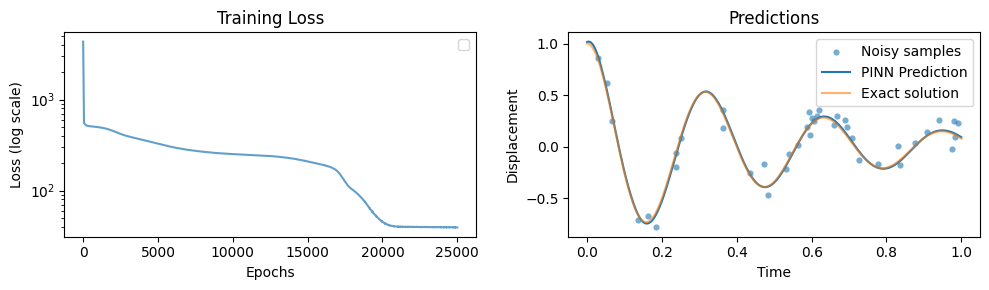

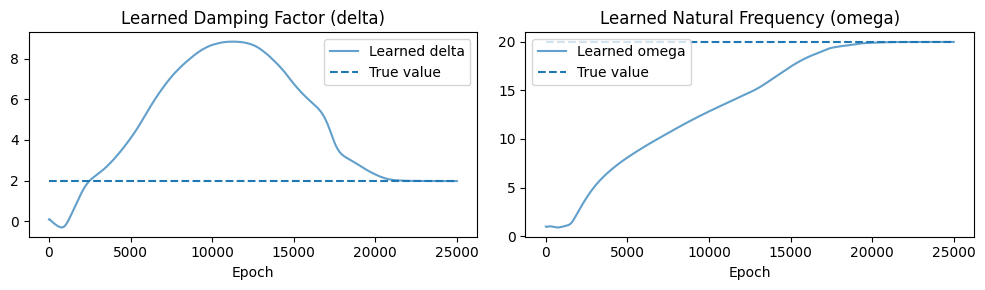

In [46]:
# ---------------------------
# Now we can also find the best configuration based on the lowest combined error for both parameters and plot the predictions and learned parameters for that configuration.
# ---------------------------
from matplotlib.pyplot import xlabel


best = min(results, key=lambda x: x["mu_error"] + x["omega_error"])
print("Best configuration:", "Number configuration:", best["config"]," LR NN:", best["lr_nn"], "LR Param:", best["lr_param"], "Lambda Phys:", best["lambda_phys"], "Lambda Data:", best["lambda_data"], "Mu Init:", best["mu_init"], "Omega Init:", best["omega_init"], "Final Mu:", best["mu_final"], "Final Omega:", best["omega_final"],"Mu Error:", best["mu_error"], "Omega Error:", best["omega_error"])


# --------------------------------------------------
# Plot loss + predictions
# --------------------------------------------------

fig, axs = pp.subplots(1, 2, figsize=(10, 3))

# ---- Loss ----
axs[0].plot(best["losses"], alpha=0.7)
axs[0].set_xlabel("Epochs")
axs[0].set_ylabel("Loss (log scale)")
axs[0].set_title("Training Loss")
axs[0].set_yscale("log")
axs[0].legend()


# ---- Prediction ----
axs[1].scatter(
    t_obs[:,0].detach().cpu(),
    y_obs[:,0].cpu(),
    s=20,
    lw=0,
    label="Noisy samples",
    alpha=0.6
)

axs[1].plot(
    t_test.cpu().numpy(),
    best["predictions"].cpu().numpy(),
    label="PINN Prediction"
)

axs[1].plot(
    t_test.cpu().numpy(),
    yexact,
    label="Exact solution",
    alpha=0.6
)

axs[1].set_title("Predictions")
axs[1].set_xlabel("Time")
axs[1].set_ylabel("Displacement")
axs[1].legend()

pp.tight_layout()
pp.show()


# --------------------------------------------------
# Plot learned parameters
# --------------------------------------------------
fig, axs = pp.subplots(1, 2, figsize=(10, 3))


# ---- Learned mu (delta) ----
axs[0].plot(
    best["learned_mu"],
    label="Learned delta",
    alpha=0.7
)

axs[0].hlines(
    delta,
    0,
    len(best["learned_mu"]),
    label="True value",
    linestyle="--"
)

axs[0].set_title("Learned Damping Factor (delta)")
axs[0].set_xlabel("Epoch")
axs[0].legend()


# ---- Learned omega ----
axs[1].plot(
    best["learned_omega"],
    label="Learned omega",
    alpha=0.7
)

axs[1].hlines(
    omega0,
    0,
    len(best["learned_omega"]),
    label="True value",
    linestyle="--"
)

axs[1].set_title("Learned Natural Frequency (omega)")
axs[1].set_xlabel("Epoch")
axs[1].legend()

pp.tight_layout()
pp.show()



